In [43]:
!pip install torch torchvision

Import Libraries


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Load Dataset

In [45]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

Check Data

In [46]:
images, labels = next(iter(train_loader))
print(images.shape)   # should be [64, 1, 28, 28]
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


Build Custom CNN

In [47]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 7 * 7)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

Initialize Model

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training Loop

In [49]:
train_losses = []
test_accuracies = []

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

Epoch 1/10 | Loss: 0.4769 | Accuracy: 0.8819
Epoch 2/10 | Loss: 0.3009 | Accuracy: 0.8934
Epoch 3/10 | Loss: 0.2526 | Accuracy: 0.9082
Epoch 4/10 | Loss: 0.2230 | Accuracy: 0.9108
Epoch 5/10 | Loss: 0.2003 | Accuracy: 0.9176
Epoch 6/10 | Loss: 0.1786 | Accuracy: 0.9200
Epoch 7/10 | Loss: 0.1608 | Accuracy: 0.9200
Epoch 8/10 | Loss: 0.1451 | Accuracy: 0.9194
Epoch 9/10 | Loss: 0.1320 | Accuracy: 0.9194
Epoch 10/10 | Loss: 0.1166 | Accuracy: 0.9218


Plot Results

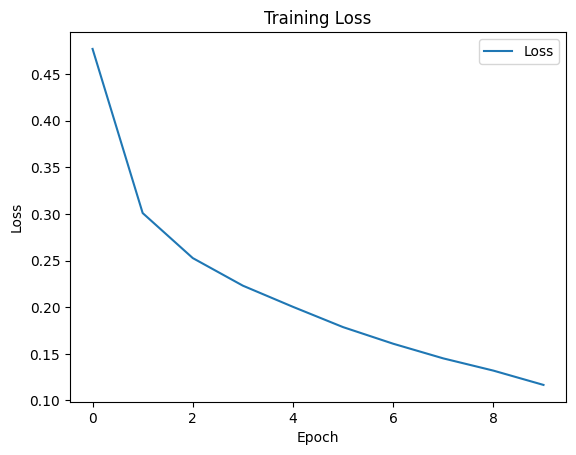

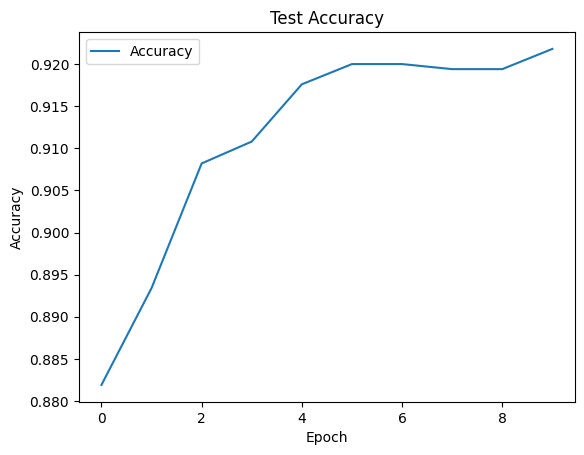

In [50]:
plt.plot(train_losses, label="Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(test_accuracies, label="Accuracy")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

BacthNorm CNN

In [51]:
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super(CNN_BatchNorm, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 64 * 7 * 7)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [52]:
model = CNN_BatchNorm().to(device)

In [53]:
train_losses_bn = []
test_accuracies_bn = []

epochs = 10

for epoch in range(epochs):
    model_bn.train()   # 🔴 changed
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_bn(images)   # 🔴 changed
        loss = criterion(outputs, labels)

        optimizer_bn.zero_grad()   # 🔴 changed
        loss.backward()
        optimizer_bn.step()        # 🔴 changed

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses_bn.append(avg_loss)   # 🔴 changed

    # Evaluation
    model_bn.eval()   # 🔴 changed
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_bn(images)   # 🔴 changed
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    test_accuracies_bn.append(accuracy)   # 🔴 changed

    print(f"[BatchNorm] Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

[BatchNorm] Epoch 1/10 | Loss: 0.4236 | Accuracy: 0.8855
[BatchNorm] Epoch 2/10 | Loss: 0.2922 | Accuracy: 0.9057
[BatchNorm] Epoch 3/10 | Loss: 0.2473 | Accuracy: 0.9062
[BatchNorm] Epoch 4/10 | Loss: 0.2217 | Accuracy: 0.9152
[BatchNorm] Epoch 5/10 | Loss: 0.1995 | Accuracy: 0.9152
[BatchNorm] Epoch 6/10 | Loss: 0.1814 | Accuracy: 0.9182
[BatchNorm] Epoch 7/10 | Loss: 0.1647 | Accuracy: 0.9192
[BatchNorm] Epoch 8/10 | Loss: 0.1507 | Accuracy: 0.9213
[BatchNorm] Epoch 9/10 | Loss: 0.1368 | Accuracy: 0.9232
[BatchNorm] Epoch 10/10 | Loss: 0.1246 | Accuracy: 0.9236


In [54]:
model_bn = CNN_BatchNorm().to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

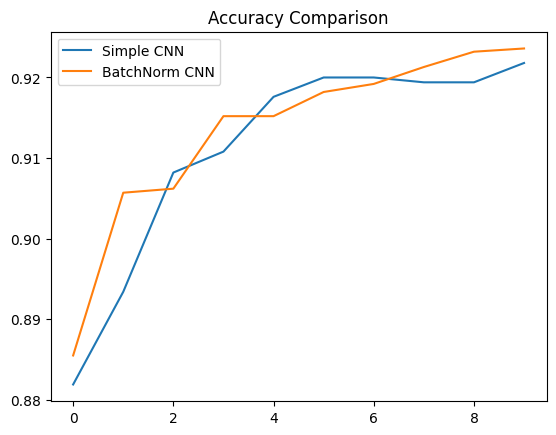

In [55]:
plt.plot(test_accuracies, label="Simple CNN")
plt.plot(test_accuracies_bn, label="BatchNorm CNN")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

Transfer Learning (ResNet18)

In [56]:
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [57]:
train_dataset_resnet = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_resnet
)

test_dataset_resnet = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_resnet
)

train_loader_resnet = torch.utils.data.DataLoader(
    train_dataset_resnet, batch_size=64, shuffle=True
)

test_loader_resnet = torch.utils.data.DataLoader(
    test_dataset_resnet, batch_size=64, shuffle=False
)

Pretrained ResNet18

In [58]:
import torchvision.models as models

model_resnet = models.resnet18(pretrained=True)

In [59]:
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)

In [60]:
model_resnet = model_resnet.to(device)

Defining Loss & Optimizer

In [61]:
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

Training Loop

In [ ]:
train_losses_resnet = []
test_accuracies_resnet = []

epochs = 3  # keep small (ResNet is heavy)

for epoch in range(epochs):
    model_resnet.train()
    running_loss = 0

    for images, labels in train_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        outputs = model_resnet(images)
        loss = criterion(outputs, labels)

        optimizer_resnet.zero_grad()
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader_resnet)
    train_losses_resnet.append(avg_loss)

    # Evaluation
    model_resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader_resnet:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    test_accuracies_resnet.append(accuracy)

    print(f"[ResNet] Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

Comparing of All Models

In [61]:
plt.plot(test_accuracies, label="Simple CNN")
plt.plot(test_accuracies_bn, label="BatchNorm CNN")
plt.plot(test_accuracies_resnet, label="ResNet18")

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()